## 1. Kiểm tra Outlier mức lương (IQR + Boxplot)

<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_18676\2984260074.py:5: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("D:\Dự án tốt nghiệp - GitHub\DATN-XLDL\du_lieu.csv")


Số lượng outlier: 1764


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
4,2025,EX,FT,Data Engineer,351410,USD,351410,US,0,US,M
40,2025,SE,FT,Data Scientist,335720,USD,335720,US,100,US,M
77,2025,SE,FT,Engineer,440000,USD,440000,US,0,US,M
81,2025,SE,FT,Research Engineer,440000,USD,440000,US,0,US,M
166,2025,MI,FT,Research Scientist,410000,USD,410000,US,0,US,M


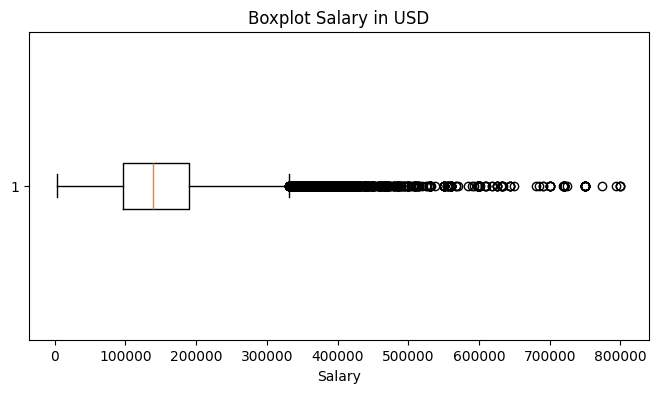

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("D:\Dự án tốt nghiệp - GitHub\DATN-XLDL\du_lieu.csv")

# Tính IQR
Q1 = df["salary_in_usd"].quantile(0.25)
Q3 = df["salary_in_usd"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Lấy outlier
outliers = df[(df["salary_in_usd"] < lower) | (df["salary_in_usd"] > upper)]

print("Số lượng outlier:", len(outliers))
display(outliers.head())

# Boxplot
plt.figure(figsize=(8,4))
plt.boxplot(df["salary_in_usd"], vert=False)
plt.title("Boxplot Salary in USD")
plt.xlabel("Salary")
plt.show()

## 2. Kiểm tra Outlier theo từng Job Title

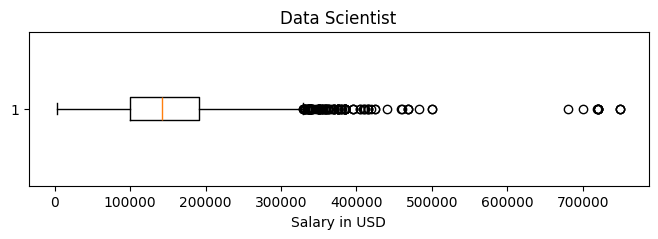

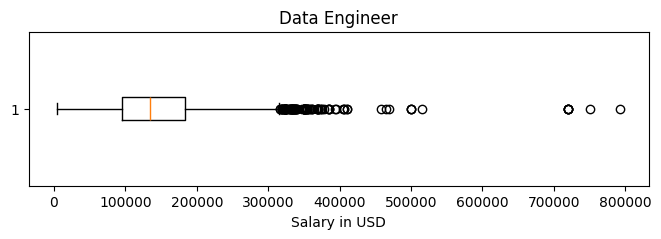

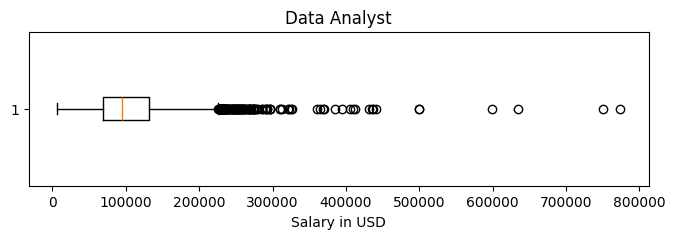

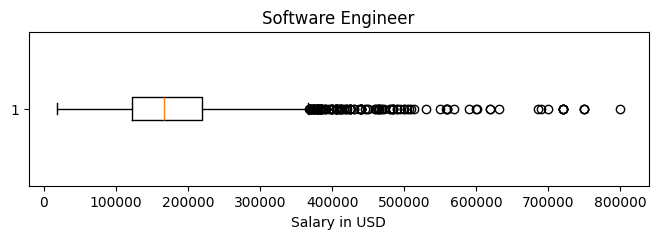

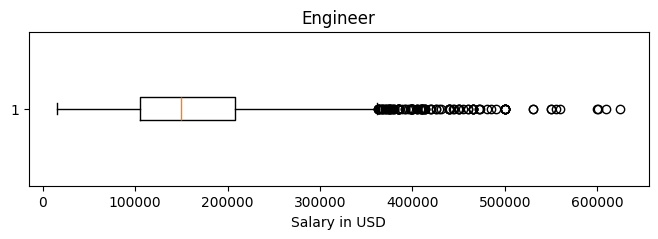

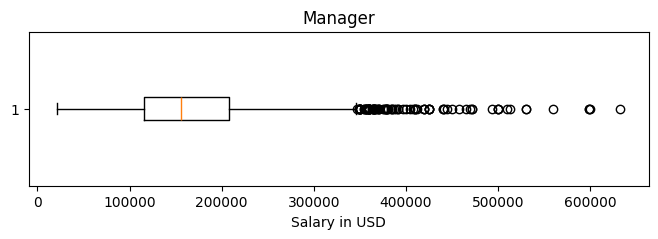

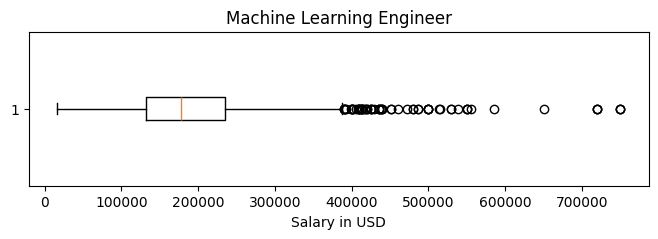

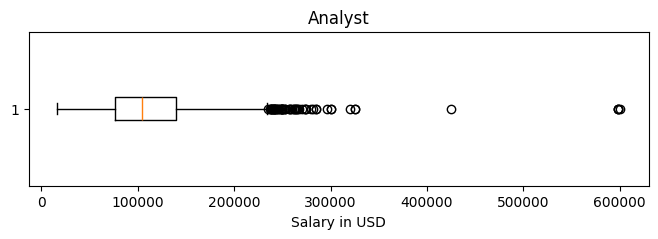

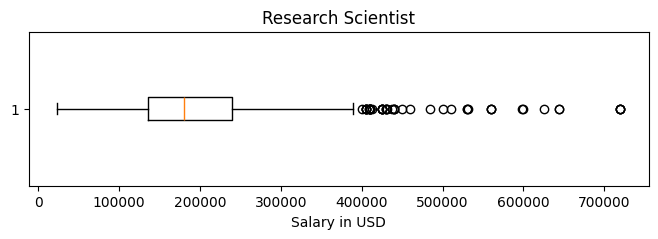

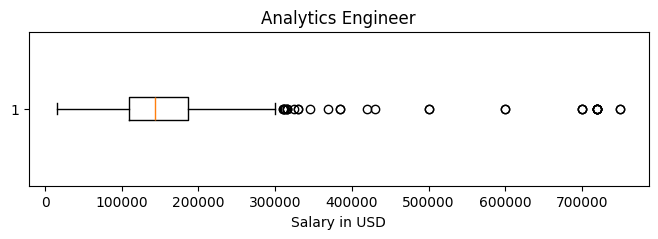

In [2]:
for job in df["job_title"].value_counts().head(10).index:
    
    temp = df[df["job_title"] == job]

    if len(temp) < 5:
        continue

    plt.figure(figsize=(8,2))
    plt.boxplot(temp["salary_in_usd"], vert=False)
    plt.title(job)
    plt.xlabel("Salary in USD")
    plt.show()

## 3. Chuẩn hóa mã quốc gia

In [3]:
country_map = {
    "US":"United States",
    "VN":"Vietnam",
    "GB":"United Kingdom",
    "CA":"Canada",
    "IN":"India",
    "JP":"Japan",
    "DE":"Germany",
    "FR":"France",
    "ES":"Spain",
    "AU":"Australia",
    "NL":"Netherlands",
    "SG":"Singapore",
    "BR":"Brazil",
    "MX":"Mexico",
    "IT":"Italy",
    "PL":"Poland",
    "PT":"Portugal",
    "CH":"Switzerland",
    "IE":"Ireland",
    "SE":"Sweden",
    "DK":"Denmark",
    "NO":"Norway",
    "FI":"Finland",
    "BE":"Belgium",
    "AT":"Austria",
    "CN":"China",
    "KR":"South Korea",
    "TR":"Turkey",
    "UA":"Ukraine",
    "AR":"Argentina",
    "NZ":"New Zealand"
}

In [4]:
df["employee_residence"] = df["employee_residence"].replace(country_map)

df["company_location"] = df["company_location"].replace(country_map)

display(df[["employee_residence","company_location"]].head())

,employee_residence,company_location
0,Netherlands,Netherlands
1,Netherlands,Netherlands
2,United States,United States
3,United States,United States
4,United States,United States


## 4. Kiểm tra còn mã ISO nào chưa chuyển

In [5]:
print("Employee Residence:")
print(sorted(df["employee_residence"].unique()))

print()

print("Company Location:")
print(sorted(df["company_location"].unique()))

Employee Residence:
['AD', 'AE', 'AM', 'AS', 'Argentina', 'Australia', 'Austria', 'BA', 'BG', 'BM', 'BO', 'Belgium', 'Brazil', 'CD', 'CF', 'CL', 'CO', 'CR', 'CY', 'CZ', 'Canada', 'China', 'DO', 'DZ', 'Denmark', 'EC', 'EE', 'EG', 'Finland', 'France', 'GE', 'GH', 'GR', 'GT', 'Germany', 'HK', 'HN', 'HR', 'HU', 'ID', 'IL', 'IQ', 'IR', 'India', 'Ireland', 'Italy', 'JE', 'JM', 'JO', 'Japan', 'KE', 'KW', 'LB', 'LS', 'LT', 'LU', 'LV', 'MD', 'MK', 'ML', 'MT', 'MU', 'MY', 'Mexico', 'NG', 'Netherlands', 'New Zealand', 'Norway', 'OM', 'PA', 'PE', 'PH', 'PK', 'PR', 'Poland', 'Portugal', 'QA', 'RO', 'RS', 'RU', 'RW', 'SA', 'SI', 'SK', 'SV', 'Singapore', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'TH', 'TN', 'TW', 'Turkey', 'UG', 'UZ', 'Ukraine', 'United Kingdom', 'United States', 'VE', 'Vietnam', 'XK', 'ZA', 'ZM']

Company Location:
['AD', 'AE', 'AM', 'AS', 'Argentina', 'Australia', 'Austria', 'BA', 'BG', 'BS', 'Belgium', 'Brazil', 'CD', 'CF', 'CL', 'CO', 'CR', 'CY', 'CZ', 'Canada', 'China', '

## 5. Lưu dataset sau khi làm sạch

In [6]:
df.to_csv("du_lieu_quoc_te_clean.csv", index=False, encoding="utf-8-sig")